# 01 - Exploración de datos — DeepWeeds

**Proyecto:** Clasificación de especies de maleza en imágenes de campo mediante CNN y transfer learning

**Curso:** Fundamentos de Deep Learning — Universidad de Antioquia, 2026-2

**Autores:** Guillermo Mejía Uribe, Daniel Duque Rivera

### ¿Qué hace este cuaderno?
Es el primer paso del proyecto: conocer bien los datos **antes** de entrenar cualquier modelo. Al final de este cuaderno debemos poder responder:

1. ¿Los datos están completos y sanos? (archivos faltantes, corruptos, duplicados)
2. ¿Cómo es el desbalance de clases y **cuánto se reduce con la estrategia jerárquica** que sugirió el profesor?
3. ¿Las particiones oficiales de Olsen et al. (2019) sirven para evaluar bien el pipeline jerárquico, sin fuga de datos?
4. ¿Qué características visuales (color, brillo) tienen las clases y qué riesgos de "atajos" puede aprender el modelo?

### Cómo ejecutarlo
`Entorno de ejecución → Ejecutar todas`. El dataset *DeepWeeds* se descarga directamente desde Kaggle ([imsparsh/deepweeds](https://www.kaggle.com/datasets/imsparsh/deepweeds)), así que no se necesita ningún archivo local. Ver la sección 2 si Kaggle pide credenciales.

## 1. Configuración del Entorno

Se cargan las librerías, se fija una semilla para que los muestreos aleatorios sean reproducibles y se define la carpeta donde se guardan las figuras usadas en el informe. Al final se registran las versiones de las librerías con las que se obtuvieron los resultados.

In [1]:
import re
import random
import hashlib
from collections import Counter
from itertools import combinations
from pathlib import Path

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DIR_FIGURAS = Path("figuras")
DIR_FIGURAS.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

print(f"pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")

pandas 2.2.3 | numpy 2.1.3 | seaborn 0.13.2


## 2. Descarga del dataset desde Kaggle

El dataset se descarga desde Kaggle ([imsparsh/deepweeds](https://www.kaggle.com/datasets/imsparsh/deepweeds)) con `kagglehub`, por lo que no se requieren archivos locales. Si Kaggle solicita autenticación, crear en Colab los secretos `KAGGLE_USERNAME` y `KAGGLE_KEY`.

Como la ruta de descarga depende de la versión del dataset, las carpetas de etiquetas e imágenes se ubican a partir del archivo `labels.csv`.

In [2]:
DATASET_KAGGLE = "imsparsh/deepweeds"


def descargar_dataset(id_dataset: str) -> Path:
    """Descarga un dataset de Kaggle con kagglehub.

    Args:
        id_dataset: Identificador en formato "usuario/nombre".

    Returns:
        Ruta local de la descarga.

    Raises:
        RuntimeError: Si la descarga falla por conexión o autenticación.
    """
    try:
        return Path(kagglehub.dataset_download(id_dataset))
    except Exception as error:
        raise RuntimeError(
            f"No se pudo descargar '{id_dataset}'. Verifique la conexión a internet "
            "o configure los secretos KAGGLE_USERNAME y KAGGLE_KEY en Colab."
        ) from error


def localizar_carpetas(raiz: Path) -> tuple[Path, Path]:
    """Ubica las carpetas de etiquetas e imágenes a partir de labels.csv.

    La ruta de kagglehub incluye la versión del dataset (p. ej. '.../versions/2/'),
    por eso se busca labels.csv en lugar de fijar la ruta.

    Args:
        raiz: Carpeta donde se descargó el dataset.

    Returns:
        Carpeta de etiquetas y carpeta de imágenes.

    Raises:
        FileNotFoundError: Si no existe labels.csv o la carpeta images.
    """
    ruta_labels = next(raiz.rglob("labels.csv"), None)
    if ruta_labels is None:
        raise FileNotFoundError(f"No se encontró labels.csv en {raiz}")

    dir_labels = ruta_labels.parent
    dir_imagenes = dir_labels.parent / "images"
    if not dir_imagenes.is_dir():
        raise FileNotFoundError(f"No se encontró la carpeta images junto a {dir_labels}")

    return dir_labels, dir_imagenes


DIR_LABELS, DIR_IMAGENES = localizar_carpetas(descargar_dataset(DATASET_KAGGLE))

print(f"Etiquetas: {DIR_LABELS}")
print(f"Imágenes : {DIR_IMAGENES}")

100%|██████████| 470M/470M [00:20<00:00, 23.6MB/s]

Extracting files...


Etiquetas: /root/.cache/kagglehub/datasets/imsparsh/deepweeds/versions/2/labels
Imágenes : /root/.cache/kagglehub/datasets/imsparsh/deepweeds/versions/2/images


## 3. Estructura del dataset

La descarga contiene dos carpetas:

- `images/`: imágenes RGB en formato JPG.
- `labels/`: el archivo `labels.csv`, con la clase de cada imagen, y 15 archivos de partición oficiales de Olsen et al. (2019): 5 folds, cada uno dividido en `train`, `val` y `test`.

In [3]:
PATRON_PARTICION = re.compile(r"^(train|val|test)_subset(\d+)\.csv$")
SUBCONJUNTOS = ["train", "val", "test"]


def tamano_en_disco_mb(carpeta: Path) -> float:
    """Tamaño total en MB de los archivos de una carpeta y sus subcarpetas."""
    return sum(f.stat().st_size for f in carpeta.rglob("*") if f.is_file()) / 1024**2


def resumir_particiones(dir_labels: Path) -> pd.DataFrame:
    """Cuenta las imágenes de cada archivo de partición oficial.

    Args:
        dir_labels: Carpeta con los archivos '{subconjunto}_subset{fold}.csv'.

    Returns:
        Una fila por fold y columnas train, val y test. Un subconjunto ausente
        aparece como NaN en lugar de provocar un error.

    Raises:
        FileNotFoundError: Si no hay archivos de partición.
    """
    registros = []
    for ruta in sorted(dir_labels.glob("*_subset*.csv")):
        coincidencia = PATRON_PARTICION.match(ruta.name)
        if coincidencia is None:
            continue
        subconjunto, fold = coincidencia.groups()
        registros.append({"fold": int(fold), "subconjunto": subconjunto,
                          "imagenes": len(pd.read_csv(ruta))})

    if not registros:
        raise FileNotFoundError(f"No se encontraron archivos de partición en {dir_labels}")

    return (pd.DataFrame(registros)
              .pivot(index="fold", columns="subconjunto", values="imagenes")
              .reindex(columns=SUBCONJUNTOS))


n_imagenes = sum(1 for _ in DIR_IMAGENES.glob("*.jpg"))

print(f"Imágenes en images/ : {n_imagenes:}")
print(f"Tamaño en disco     : {tamano_en_disco_mb(DIR_LABELS.parent):,.0f} MB")
print(f"labels.csv presente : {(DIR_LABELS / 'labels.csv').is_file()}")

display(resumir_particiones(DIR_LABELS))

Imágenes en images/ : 17509
Tamaño en disco     : 472 MB
labels.csv presente : True


subconjunto,train,val,test
fold,,,
0,10501,3501,3507
1,10504,3502,3503
2,10506,3502,3501
3,10506,3503,3500
4,10508,3503,3498


## 4. Archivo de etiquetas

`labels.csv` asocia cada imagen con su clase mediante dos columnas equivalentes: `Label` (entero 0–8) y `Species` (nombre). Se verifica que la correspondencia entre ambas sea uno a uno y se identifica el `Label` de la clase **Negative**, necesario para construir las etiquetas de la estrategia jerárquica.

In [4]:
COLUMNAS_ETIQUETAS = {"Filename", "Label", "Species"}


def cargar_etiquetas(dir_labels: Path) -> pd.DataFrame:
    """Carga labels.csv y valida sus columnas.

    Args:
        dir_labels: Carpeta que contiene labels.csv.

    Returns:
        Una fila por imagen con las columnas Filename, Label y Species.

    Raises:
        ValueError: Si falta alguna columna esperada.
    """
    etiquetas = pd.read_csv(dir_labels / "labels.csv")
    faltantes = COLUMNAS_ETIQUETAS - set(etiquetas.columns)
    if faltantes:
        raise ValueError(f"Columnas faltantes en labels.csv: {sorted(faltantes)}")
    return etiquetas


def mapear_clases(etiquetas: pd.DataFrame) -> dict[int, str]:
    """Construye el mapeo Label → Species y verifica que sea uno a uno.

    Un mapeo que no sea uno a uno fusionaría especies distintas o partiría una
    especie en varias clases, sin que el entrenamiento lo detecte.

    Args:
        etiquetas: Debe contener las columnas Label y Species.

    Returns:
        Nombre de la especie para cada Label.

    Raises:
        ValueError: Si la correspondencia no es uno a uno.
    """
    pares = etiquetas[["Label", "Species"]].drop_duplicates()
    if pares["Label"].duplicated().any() or pares["Species"].duplicated().any():
        raise ValueError("La correspondencia entre Label y Species no es uno a uno.")
    return dict(zip(pares["Label"], pares["Species"]))


etiquetas = cargar_etiquetas(DIR_LABELS)
LABEL_A_ESPECIE = dict(sorted(mapear_clases(etiquetas).items()))
LABEL_NEGATIVE = next(label for label, especie in LABEL_A_ESPECIE.items() if especie == "Negative")

print(f"Filas: {len(etiquetas):} | Columnas: {list(etiquetas.columns)}")
display(etiquetas.head())
display(pd.Series(LABEL_A_ESPECIE, name="Species").rename_axis("Label").to_frame())
print(f"Clase Negative → Label {LABEL_NEGATIVE}")

Filas: 17509 | Columnas: ['Filename', 'Label', 'Species']


,Filename,Label,Species
0,20160928-140314-0.jpg,0,Chinee apple
1,20160928-140337-0.jpg,0,Chinee apple
2,20160928-140731-0.jpg,0,Chinee apple
3,20160928-140747-0.jpg,0,Chinee apple
4,20160928-141107-0.jpg,0,Chinee apple


,Species
Label,
0,Chinee apple
1,Lantana
2,Parkinsonia
3,Parthenium
4,Prickly acacia
5,Rubber vine
6,Siam weed
7,Snake weed
8,Negative


Clase Negative → Label 8


**Observación:** la correspondencia entre `Label` y `Species` es uno a uno y coincide con el orden de clases de Olsen et al. (2019). La clase **Negative** corresponde al `Label` 8.

## 5. Auditoría de integridad

Se inspeccionan **todas** las imágenes, no una muestra, para verificar:

| Verificación | Por qué importa |
|---|---|
| Correspondencia entre labels.csv y la carpeta | Una etiqueta sin imagen detiene el entrenamiento a mitad de una época. |
| Imágenes corruptas | Mismo efecto, pero más difícil de rastrear. |
| Duplicados exactos (hash MD5) | Una misma imagen en train y en test infla las métricas. |
| Dimensiones y modo de color | Define si se requiere `resize` y cuántos canales recibe la red. |

La ejecución toma alrededor de un minuto, porque decodifica las 17509 imágenes.

In [5]:
EXTENSIONES_IMAGEN = {".jpg", ".jpeg", ".png"}


def inspeccionar_imagen(ruta: Path) -> dict:
    """Obtiene hash, dimensiones y modo de color de una imagen y verifica que se pueda decodificar.

    Se usa 'load()' en lugar de 'verify()' porque 'verify()' no decodifica los
    píxeles y deja pasar archivos JPG truncados.

    Args:
        ruta: Ruta de la imagen.

    Returns:
        Campos existe, corrupta, md5, ancho, alto y modo. Los que no se
        pueden obtener quedan en None.
    """
    registro = {"existe": ruta.is_file(), "corrupta": False,
                "md5": None, "ancho": None, "alto": None, "modo": None}
    if not registro["existe"]:
        return registro

    registro["md5"] = hashlib.md5(ruta.read_bytes()).hexdigest()
    try:
        with Image.open(ruta) as imagen:
            registro["ancho"], registro["alto"] = imagen.size
            registro["modo"] = imagen.mode
            imagen.load()
    except (OSError, SyntaxError, ValueError):
        registro["corrupta"] = True
    return registro


def auditar_imagenes(nombres: pd.Series, carpeta: Path) -> pd.DataFrame:
    """Inspecciona cada imagen referenciada en las etiquetas.

    Args:
        nombres: Nombres de archivo listados en labels.csv.
        carpeta: Carpeta que contiene las imágenes.

    Returns:
        Una fila por imagen con Filename y los campos de 'inspeccionar_imagen'.
    """
    return pd.DataFrame([{"Filename": nombre, **inspeccionar_imagen(carpeta / nombre)}
                         for nombre in nombres])


def agrupar_duplicados(auditoria: pd.DataFrame) -> list[list[str]]:
    """Agrupa las imágenes con contenido idéntico según su hash MD5.

    Args:
        auditoria: Resultado de 'auditar_imagenes'.

    Returns:
        Grupos de nombres de archivo con dos o más imágenes idénticas.
    """
    grupos = auditoria.dropna(subset=["md5"]).groupby("md5")["Filename"].apply(list)
    return [grupo for grupo in grupos if len(grupo) > 1]


auditoria = auditar_imagenes(etiquetas["Filename"], DIR_IMAGENES)
en_carpeta = {ruta.name for ruta in DIR_IMAGENES.iterdir()
              if ruta.suffix.lower() in EXTENSIONES_IMAGEN}
duplicados = agrupar_duplicados(auditoria)

resumen_integridad = pd.Series({
    "Filas en labels.csv": len(etiquetas),
    "Imágenes en la carpeta": len(en_carpeta),
    "Etiquetas sin imagen": int((~auditoria["existe"]).sum()),
    "Imágenes sin etiqueta": len(en_carpeta - set(etiquetas["Filename"])),
    "Imágenes corruptas": int(auditoria["corrupta"].sum()),
    "Grupos de duplicados exactos": len(duplicados),
}, name="Cantidad")

display(resumen_integridad.to_frame())
display(auditoria.value_counts(["ancho", "alto", "modo"]).to_frame("Imágenes"))

,Cantidad
Filas en labels.csv,17509
Imágenes en la carpeta,17509
Etiquetas sin imagen,0
Imágenes sin etiqueta,0
Imágenes corruptas,0
Grupos de duplicados exactos,0


,,,Imágenes
ancho,alto,modo,
256,256,RGB,17509


**Observación:** el dataset está completo y sin errores: las 17509 imágenes tienen etiqueta, ninguna está corrupta ni duplicada, y todas son RGB de 256×256 píxeles. No se requiere limpieza; el único ajuste de formato será redimensionar a la entrada de cada backbone (224×224) en el cuaderno de preprocesado.

## 6. Distribución de clases y desbalance

El desbalance se mide con el ratio $\rho = \max_k n_k \,/\, \min_k n_k$, donde $n_k$ es el número de imágenes de la clase $k$ ($\rho = 1$ indica balance perfecto). Se compara para tres formulaciones del problema:

1. **Plano:** una sola red clasifica las 9 clases.
2. **Etapa 1 - binaria:** Negative vs. Positiva (las 8 especies agrupadas).
3. **Etapa 2 - especies:** solo imágenes positivas, clasificadas en 8 especies.

,Imágenes,%
Species,,
Negative,9106,52.0
Chinee apple,1125,6.4
Siam weed,1074,6.1
Lantana,1064,6.1
Prickly acacia,1062,6.1
Parkinsonia,1031,5.9
Parthenium,1022,5.8
Snake weed,1016,5.8
Rubber vine,1009,5.8


,ρ = máx / mín
Plano (9 clases),9.02
Etapa 1: Negative vs. Positiva,1.08
Etapa 2: 8 especies,1.11


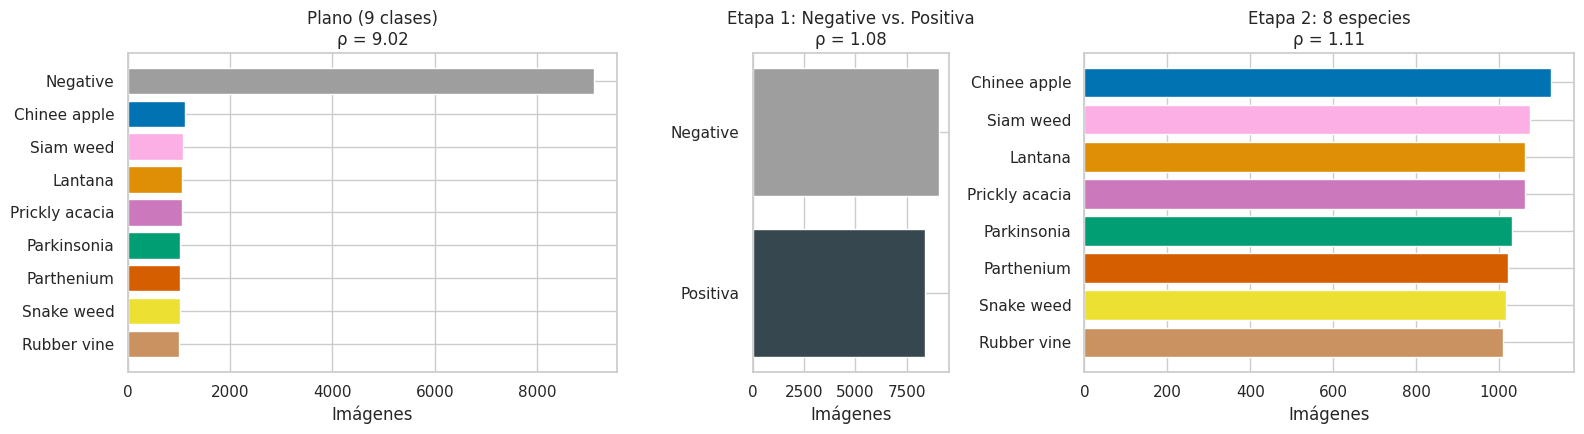

In [6]:
def ratio_desbalance(clases: pd.Series) -> float:
    """Cociente entre la clase más frecuente y la menos frecuente (1 = balance perfecto)."""
    conteo = clases.value_counts()
    return conteo.max() / conteo.min()


def vistas_jerarquicas(etiquetas: pd.DataFrame, label_negative: int) -> dict[str, pd.Series]:
    """Construye las etiquetas de cada formulación del problema.

    Las tres vistas se derivan de las mismas filas: no se crean ni eliminan
    imágenes, solo cambia la pregunta que se le hace al modelo.

    Args:
        etiquetas: Debe contener las columnas Label y Species.
        label_negative: Label de la clase Negative.

    Returns:
        Etiquetas del problema plano, de la etapa 1 (Negative vs. Positiva) y de
        la etapa 2 (solo imágenes positivas).
    """
    es_negative = etiquetas["Label"] == label_negative
    return {
        "Plano (9 clases)": etiquetas["Species"],
        "Etapa 1: Negative vs. Positiva": es_negative.map({True: "Negative", False: "Positiva"}),
        "Etapa 2: 8 especies": etiquetas.loc[~es_negative, "Species"],
    }


def asignar_colores(label_a_especie: dict[int, str]) -> dict[str, tuple]:
    """Asigna un color fijo a cada clase para usarlo en todas las figuras del cuaderno.

    Las especies toman colores de la paleta 'colorblind', excepto el gris, que se
    reserva para Negative. La clase agregada Positiva usa un tono oscuro neutro.

    Args:
        label_a_especie: Mapeo Label → Species.

    Returns:
        Color de cada clase, incluidas Negative y Positiva.
    """
    especies = [especie for especie in label_a_especie.values() if especie != "Negative"]
    paleta = [color for i, color in enumerate(sns.color_palette("colorblind")) if i != 7]
    colores = dict(zip(especies, paleta))
    colores["Negative"] = "#9e9e9e"
    colores["Positiva"] = "#37474f"
    return colores


def graficar_vistas(vistas: dict[str, pd.Series], colores: dict[str, tuple],
                    ruta_salida: Path) -> None:
    """Grafica la distribución de clases de cada vista y guarda la figura."""
    fig, ejes = plt.subplots(1, len(vistas), figsize=(16, 4.5),
                             gridspec_kw={"width_ratios": [3, 1.2, 3]})
    for eje, (nombre, clases) in zip(ejes, vistas.items()):
        conteo = clases.value_counts().sort_values()
        eje.barh(conteo.index, conteo.values, color=[colores[clase] for clase in conteo.index])
        eje.set_title(f"{nombre}\nρ = {ratio_desbalance(clases):.2f}")
        eje.set_xlabel("Imágenes")
    fig.tight_layout()
    fig.savefig(ruta_salida, bbox_inches="tight")
    plt.show()


vistas = vistas_jerarquicas(etiquetas, LABEL_NEGATIVE)

distribucion = etiquetas["Species"].value_counts().to_frame("Imágenes")
distribucion["%"] = (100 * distribucion["Imágenes"] / len(etiquetas)).round(1)
display(distribucion)

display(pd.Series({nombre: ratio_desbalance(clases) for nombre, clases in vistas.items()},
                  name="ρ = máx / mín").round(2).to_frame())

COLORES_CLASE = asignar_colores(LABEL_A_ESPECIE)
graficar_vistas(vistas, COLORES_CLASE, DIR_FIGURAS / "desbalance_plano_vs_jerarquico.png")

**Observación:**
- El ratio pasa de 9.02 (plano) a 1.08 (etapa 1) y 1.11 (etapa 2). El desbalance no está en la cantidad de imágenes de cada especie, sino en cómo se formula el problema. Negative es una clase que agrupa todo lo que no es maleza objetivo, por eso tiene casi tantas imágenes como las 8 especies juntas. Si se pone a competir uno a uno contra cada especie en una sola salida (problema plano), aparece el ratio de 9.02. Si se compara contra las malezas agrupadas (etapa 1), el ratio baja a 1.08.
- Sin embargo, que las especies estén balanceadas (etapa 2) no garantiza que el modelo las vaya a reconocer igual de bien: Olsen et al. (2019, Tablas 2 y 3) reportan que Chinee apple, la especie con más imágenes, obtuvo la menor accuracy con ResNet-50 (88.5 %) y también con Inception-v3 (85.3 %), principalmente por su similitud visual con Snake weed.

## 7. Particiones oficiales

Se usan las 5 particiones de Olsen et al. (2019) para que los resultados sean comparables con la literatura. Para la estrategia jerárquica **no se crean particiones nuevas por etapa**: la etapa 1 y la etapa 2 son vistas de la misma partición (la etapa 2 solo filtra las imágenes positivas). Así, ninguna imagen de test participa en el entrenamiento de ninguna etapa, y el sistema completo se puede evaluar *end-to-end* sobre un mismo test.

`labels.csv` es la fuente de verdad de las etiquetas. Los archivos de partición solo definen a qué subconjunto pertenece cada imagen.

Para cada fold se verifica:
1. Que train, val y test no compartan imágenes.
2. Que el fold cubra todo el dataset y que sus etiquetas coincidan con `labels.csv`.
3. Que las proporciones de cada etapa se mantengan en train, val y test.

### Verificación del fold y proporciones

In [7]:
N_FOLDS = 5


def cargar_fold(dir_labels: Path, fold: int) -> dict[str, pd.DataFrame]:
    """Carga los subconjuntos train, val y test de un fold oficial.

    Args:
        dir_labels: Carpeta con los archivos '{subconjunto}_subset{fold}.csv'.
        fold: Número del fold.

    Returns:
        DataFrame de cada subconjunto, con las columnas Filename y Label.

    Raises:
        FileNotFoundError: Si falta alguno de los tres archivos del fold.
    """
    rutas = {sub: dir_labels / f"{sub}_subset{fold}.csv" for sub in SUBCONJUNTOS}
    faltantes = [ruta.name for ruta in rutas.values() if not ruta.is_file()]
    if faltantes:
        raise FileNotFoundError(f"Fold {fold}: faltan los archivos {faltantes}")
    return {sub: pd.read_csv(ruta) for sub, ruta in rutas.items()}


def etiquetas_discrepantes(particion: dict[str, pd.DataFrame],
                           etiquetas: pd.DataFrame) -> pd.DataFrame:
    """Devuelve las imágenes cuyo Label en la partición difiere del de labels.csv.

    Args:
        particion: Subconjuntos del fold, resultado de 'cargar_fold'.
        etiquetas: Etiquetas maestras con las columnas Filename, Label y Species.

    Returns:
        Filas con Filename, Label de la partición, Label y Species de labels.csv.
    """
    unidas = pd.concat(particion.values()).merge(etiquetas, on="Filename",
                                                 how="left", suffixes=("_particion", ""))
    return unidas.loc[unidas["Label_particion"] != unidas["Label"],
                      ["Filename", "Label_particion", "Label", "Species"]]


def verificar_fold(particion: dict[str, pd.DataFrame], etiquetas: pd.DataFrame) -> dict:
    """Verifica que un fold no tenga fuga de datos y sea coherente con labels.csv.

    Args:
        particion: Subconjuntos del fold, resultado de 'cargar_fold'.
        etiquetas: Etiquetas maestras con las columnas Filename y Label.

    Returns:
        Imágenes compartidas por cada par de subconjuntos, si el fold cubre todo
        el dataset y cuántas etiquetas difieren de labels.csv.
    """
    nombres = {sub: set(df["Filename"]) for sub, df in particion.items()}
    resultado = {f"{a} ∩ {b}": len(nombres[a] & nombres[b])
                 for a, b in combinations(SUBCONJUNTOS, 2)}
    resultado["cubre todo"] = set().union(*nombres.values()) == set(etiquetas["Filename"])
    resultado["etiquetas distintas"] = len(etiquetas_discrepantes(particion, etiquetas))
    return resultado


def proporciones_jerarquicas(particion: dict[str, pd.DataFrame], etiquetas: pd.DataFrame,
                             label_negative: int) -> dict:
    """Calcula el porcentaje de Negative y los ratios de cada etapa por subconjunto.

    Las clases se toman de labels.csv (fuente de verdad); la partición solo
    define a qué subconjunto pertenece cada imagen.

    Args:
        particion: Subconjuntos del fold, resultado de 'cargar_fold'.
        etiquetas: Etiquetas maestras con las columnas Filename y Label.
        label_negative: Label de la clase Negative.

    Returns:
        Por subconjunto: % Negative, ρ de la etapa 1 y ρ de la etapa 2.
    """
    label_maestro = etiquetas.set_index("Filename")["Label"]
    filas = {}
    for sub, df in particion.items():
        labels = df["Filename"].map(label_maestro)
        es_negative = labels == label_negative
        filas[sub] = {"% Negative": round(100 * es_negative.mean(), 1),
                      "ρ etapa 1": round(ratio_desbalance(es_negative), 2),
                      "ρ etapa 2": round(ratio_desbalance(labels[~es_negative]), 2)}
    return filas


FOLDS = {fold: cargar_fold(DIR_LABELS, fold) for fold in range(N_FOLDS)}

verificacion = pd.DataFrame({fold: verificar_fold(p, etiquetas) for fold, p in FOLDS.items()}).T
verificacion.index.name = "fold"
display(verificacion)

columnas_fuga = [f"{a} ∩ {b}" for a, b in combinations(SUBCONJUNTOS, 2)]
if verificacion[columnas_fuga].to_numpy().any():
    raise ValueError("Hay imágenes compartidas entre subconjuntos de un mismo fold.")

proporciones = pd.concat({fold: pd.DataFrame(proporciones_jerarquicas(p, etiquetas, LABEL_NEGATIVE)).T
                          for fold, p in FOLDS.items()}, names=["fold", "subconjunto"])
display(proporciones.unstack("subconjunto"))

,train ∩ val,train ∩ test,val ∩ test,cubre todo,etiquetas distintas
fold,,,,,
0,0,0,0,True,1
1,0,0,0,True,1
2,0,0,0,True,1
3,0,0,0,True,1
4,0,0,0,True,1


% Negative             ρ etapa 1             ρ etapa 2            
subconjunto      train   val  test     train   val  test     train   val  test
fold                                                                          
0                 52.0  52.0  52.0      1.08  1.08  1.08      1.11  1.11  1.12
1                 52.0  52.0  52.0      1.08  1.08  1.08      1.12  1.11  1.11
2                 52.0  52.0  52.0      1.08  1.08  1.08      1.12  1.11  1.11
3                 52.0  52.0  52.0      1.08  1.08  1.08      1.12  1.11  1.11
4                 52.0  52.0  52.1      1.08  1.08  1.09      1.11  1.11  1.12

### ¿Cada imagen se evalúa una sola vez?

Se verifica si los test de los 5 folds son disjuntos (validación cruzada: cada imagen se evalúa una sola vez) o sorteos independientes que pueden repetir imágenes. Esto define cómo se interpretan los promedios entre folds.

In [8]:
apariciones_en_test = Counter(nombre for p in FOLDS.values() for nombre in p["test"]["Filename"])
veces_en_test = etiquetas["Filename"].map(apariciones_en_test).fillna(0).astype(int)
display(veces_en_test.value_counts().sort_index()
        .rename_axis("veces en test").to_frame("imágenes"))

,imágenes
veces en test,
1,17509


### Discrepancias de etiquetas

,Filename,Label_particion,Label,Species,Species_particion
1855,20170714-110407-3.jpg,0,1,Lantana,Chinee apple


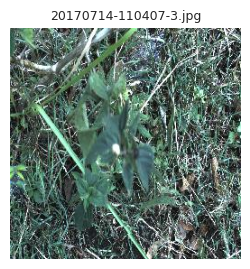

In [9]:
discrepancias = (pd.concat(etiquetas_discrepantes(p, etiquetas) for p in FOLDS.values())
                   .drop_duplicates()
                   .assign(Species_particion=lambda d: d["Label_particion"].map(LABEL_A_ESPECIE)))
display(discrepancias)

for nombre in discrepancias["Filename"]:
    plt.figure(figsize=(3, 3))
    with Image.open(DIR_IMAGENES / nombre) as imagen:
        plt.imshow(np.asarray(imagen))
    plt.title(nombre, fontsize=9)
    plt.axis("off")
    plt.show()

**Observación:**
- Los 5 folds no comparten imágenes entre train, val y test, cubren todo el dataset y mantienen las mismas proporciones de clases (≈52 % Negative, ρ ≈ 1.08 en la etapa 1 y ≈ 1.11 en la etapa 2).
- Cada imagen aparece en el test de exactamente un fold, por lo que las particiones forman una validación cruzada de 5 folds.
- Se encontró una imagen (`20170714-110407-3.jpg`) etiquetada como Lantana en `labels.csv` y como Chinee apple en los archivos de partición de los 5 folds. **Decisión:** `labels.csv` se toma como fuente de verdad, por ser el archivo maestro del dataset e incluir el nombre de la especie; los archivos de partición se usan solo para asignar cada imagen a train, val o test. El impacto en las métricas es despreciable (1 de 17509 imágenes).

## 8. Riesgo de fuga por imágenes casi idénticas

El hash MD5 solo detecta duplicados exactos. Sin embargo, las imágenes se capturaron en ráfaga: dos fotos de la misma planta tomadas con segundos de diferencia pueden ser casi iguales y tener hashes distintos. Si quedan en subconjuntos diferentes, el modelo podría acertar por memoria y no por generalización.

El nombre de cada imagen sigue el formato `AAAAMMDD-HHMMSS-ID`, donde ID identifica el instrumento que tomó la foto (repositorio oficial de DeepWeeds). Con esta información se analiza:

1. Cuántas especies se fotografiaron cada día de captura.
2. La relación entre instrumento y especie.
3. Qué porcentaje del test tiene una imagen de la misma clase en train capturada a pocos segundos ("gemela temporal"), tanto en la partición de Olsen et al. (2019) como en una partición simulada del tipo usado por Duong et al. (2024).

Este análisis es una aproximación: la cercanía en el tiempo sugiere, pero no prueba, que dos imágenes sean casi idénticas.

Días de captura: 60 | Días con una sola especie de maleza: 21


instrumento,0,1,2,3,4,Total
Species,,,,,,
Chinee apple,661,200,263,0,1,1125
Lantana,403,311,177,173,0,1064
Negative,358,2627,4457,1664,0,9106
Parkinsonia,0,350,330,351,0,1031
Parthenium,0,464,396,136,26,1022
Prickly acacia,1,518,233,310,0,1062
Rubber vine,0,482,166,361,0,1009
Siam weed,130,469,193,282,0,1074
Snake weed,860,2,139,15,0,1016


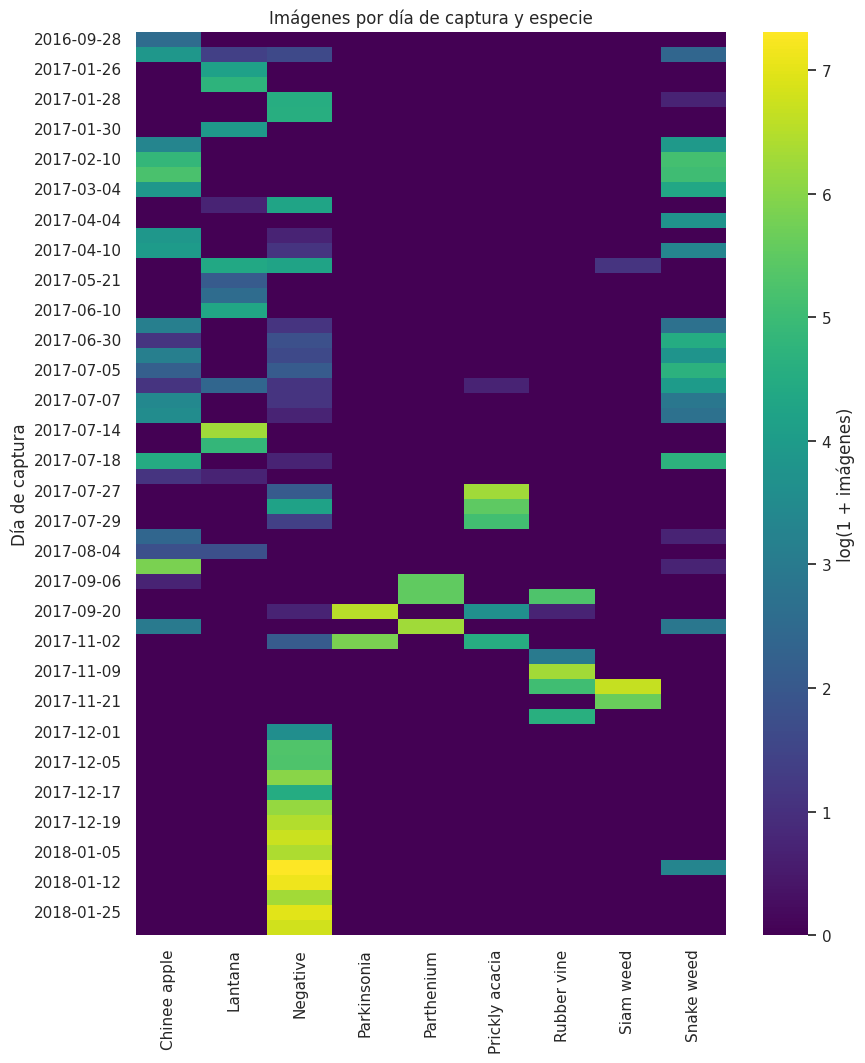

In [10]:
PATRON_NOMBRE = re.compile(r"^(?P<fecha>\d{8})-(?P<hora>\d{6})-(?P<instrumento>\d)\.jpg$")


def extraer_metadatos(nombres: pd.Series) -> pd.DataFrame:
    """Extrae fecha, momento de captura e instrumento del nombre de cada imagen.

    El formato 'AAAAMMDD-HHMMSS-ID.jpg' está documentado en el repositorio oficial.
    ID identifica el instrumento: la documentación indica valores 0–3, pero los
    datos incluyen también el 4.

    Args:
        nombres: Nombres de archivo de las imágenes.

    Returns:
        Columnas fecha, momento (datetime) e instrumento, alineadas con 'nombres'.

    Raises:
        ValueError: Si algún nombre no sigue el formato esperado.
    """
    partes = nombres.str.extract(PATRON_NOMBRE)
    invalidos = nombres[partes["fecha"].isna()]
    if not invalidos.empty:
        raise ValueError(f"{len(invalidos)} nombres no siguen el formato, p. ej. {invalidos.iloc[0]}")
    return pd.DataFrame({
        "fecha": pd.to_datetime(partes["fecha"], format="%Y%m%d"),
        "momento": pd.to_datetime(partes["fecha"] + partes["hora"], format="%Y%m%d%H%M%S"),
        "instrumento": partes["instrumento"].astype(int),
    }, index=nombres.index)


metadatos = pd.concat([etiquetas, extraer_metadatos(etiquetas["Filename"])], axis=1)

sesiones = metadatos.groupby("fecha").agg(
    imagenes=("Filename", "size"),
    especies=("Species", lambda s: s[s != "Negative"].nunique()))
print(f"Días de captura: {len(sesiones)} | "
      f"Días con una sola especie de maleza: {(sesiones['especies'] == 1).sum()}")

display(pd.crosstab(metadatos["Species"], metadatos["instrumento"],
                    margins=True, margins_name="Total"))

tabla_dias = pd.crosstab(metadatos["fecha"].dt.strftime("%Y-%m-%d"), metadatos["Species"])
fig, eje = plt.subplots(figsize=(9, max(4, min(30, 0.18 * len(tabla_dias)))))
sns.heatmap(np.log1p(tabla_dias), cmap="viridis", cbar_kws={"label": "log(1 + imágenes)"}, ax=eje)
eje.set(title="Imágenes por día de captura y especie", xlabel="", ylabel="Día de captura")
fig.tight_layout()
fig.savefig(DIR_FIGURAS / "capturas_por_dia_y_especie.png", bbox_inches="tight")
plt.show()

metadatos_por_nombre = metadatos.set_index("Filename")

### Gemelas temporales: partición de Olsen et al. vs. partición tipo Duong et al.

Se compara el porcentaje del test que tiene una "gemela temporal" en train en dos tipos de partición: el fold 0 oficial de Olsen et al. (2019, 60/20/20) y una partición aleatoria 80/10/10 como la descrita por Duong et al. (2024). Esta última es una simulación: Duong et al. no publicaron su partición exacta.

In [11]:
PARTICION_TIPO_DUONG = {"train": 0.8, "val": 0.1, "test": 0.1}
VENTANAS_S = (5, 30, 60, 300)


def proporcion_con_gemela(train: pd.Series, test: pd.Series, metadatos: pd.DataFrame,
                          ventana_s: int) -> float:
    """Calcula el porcentaje del test con una "gemela temporal" en train.

    Una gemela es una imagen de train de la misma clase capturada a menos de
    'ventana_s' segundos, es decir, de la misma sesión de captura. La cercanía
    en el tiempo no implica que las imágenes sean casi idénticas.

    Args:
        train: Nombres de archivo del subconjunto de entrenamiento.
        test: Nombres de archivo del subconjunto de prueba.
        metadatos: Indexado por Filename, con las columnas momento y Label.
        ventana_s: Diferencia máxima en segundos para considerar dos fotos gemelas.

    Returns:
        Porcentaje del test con al menos una gemela en train.
    """
    segundos = (metadatos["momento"] - pd.Timestamp("1970-01-01")) // pd.Timedelta(seconds=1)
    con_gemela = 0
    for label, nombres_test in test.groupby(metadatos.loc[test, "Label"].to_numpy()):
        nombres_train = train[metadatos.loc[train, "Label"].to_numpy() == label]
        if nombres_train.empty:
            continue
        t_train = np.sort(segundos.loc[nombres_train].to_numpy())
        t_test = segundos.loc[nombres_test].to_numpy()
        posicion = np.clip(np.searchsorted(t_train, t_test), 1, len(t_train) - 1)
        distancia = np.minimum(np.abs(t_test - t_train[posicion - 1]),
                               np.abs(t_test - t_train[posicion]))
        con_gemela += int((distancia <= ventana_s).sum())
    return 100 * con_gemela / len(test)


def simular_particion_aleatoria(nombres: pd.Series, fracciones: dict[str, float],
                                semilla: int) -> dict[str, pd.Series]:
    """Divide las imágenes al azar, sin estratificar ni agrupar por tiempo.

    Reproduce el tipo de partición descrito por Duong et al. (2024); no es su
    partición exacta, que no fue publicada.

    Args:
        nombres: Nombres de archivo de todas las imágenes.
        fracciones: Proporción de cada subconjunto, p. ej. {"train": 0.8, ...}.
        semilla: Semilla para que la división sea reproducible.

    Returns:
        Nombres de archivo de cada subconjunto.

    Raises:
        ValueError: Si las fracciones no suman 1.
    """
    if not np.isclose(sum(fracciones.values()), 1):
        raise ValueError(f"Las fracciones deben sumar 1: {fracciones}")
    barajados = nombres.sample(frac=1, random_state=semilla).reset_index(drop=True)
    limites = np.concatenate([[0], np.cumsum([round(f * len(barajados)) for f in fracciones.values()])])
    limites[-1] = len(barajados)
    return {sub: barajados.iloc[inicio:fin]
            for sub, inicio, fin in zip(fracciones, limites[:-1], limites[1:])}


particion_duong = simular_particion_aleatoria(etiquetas["Filename"], PARTICION_TIPO_DUONG, SEED)

comparacion_gemelas = pd.DataFrame({
    "Olsen et al. — fold 0 (60/20/20)": {
        ventana: proporcion_con_gemela(FOLDS[0]["train"]["Filename"], FOLDS[0]["test"]["Filename"],
                                       metadatos_por_nombre, ventana)
        for ventana in VENTANAS_S},
    "Simulación tipo Duong et al. (80/10/10)": {
        ventana: proporcion_con_gemela(particion_duong["train"], particion_duong["test"],
                                       metadatos_por_nombre, ventana)
        for ventana in VENTANAS_S},
}).rename_axis("ventana (s)").round(1)
display(comparacion_gemelas)

,Olsen et al. — fold 0 (60/20/20),Simulación tipo Duong et al. (80/10/10)
ventana (s),,
5,24.4,31.1
30,85.6,91.8
60,94.7,97.4
300,99.4,99.7


### Casi duplicados visuales (hash perceptual)

La cercanía en el tiempo sugiere, pero no prueba, que dos imágenes sean casi idénticas. Para comprobarlo sobre el contenido de las imágenes se usa un hash perceptual por diferencias (dHash): imágenes visualmente iguales producen hashes que difieren en pocos bits (distancia de Hamming), aunque cambien levemente el brillo, la compresión o el encuadre.

Para cada imagen de test del fold 0 se busca la imagen de train más parecida. Como no existe un umbral único para considerar dos imágenes casi duplicadas, se reportan varios y se validan visualmente con los pares más cercanos. El resultado es un mínimo: fotos de la misma planta tomadas desde otro ángulo pueden no ser detectadas.

In [12]:
LADO_HASH = 8
DISTANCIAS_HASH = (0, 2, 4, 6, 8, 10)
PARES_A_MOSTRAR = 5
BITS_POR_BYTE = np.unpackbits(np.arange(256, dtype=np.uint8)[:, None], axis=1).sum(axis=1)


def hash_diferencial(ruta: Path, lado: int = LADO_HASH) -> np.ndarray:
    """Calcula el hash perceptual por diferencias (dHash) de una imagen.

    La imagen se reduce a escala de grises de (lado + 1) × lado píxeles y cada
    bit indica si un píxel es más claro que su vecino de la derecha. Imágenes
    casi iguales producen hashes que difieren en pocos bits, aunque cambien
    levemente el brillo, la compresión o el encuadre.

    Args:
        ruta: Ruta de la imagen.
        lado: Lado de la cuadrícula; el hash tiene lado² bits.

    Returns:
        Hash empaquetado en bytes, con shape (lado² / 8,).
    """
    with Image.open(ruta) as imagen:
        gris = np.asarray(imagen.convert("L").resize((lado + 1, lado), Image.LANCZOS), dtype=np.int16)
    return np.packbits(gris[:, 1:] > gris[:, :-1])


def vecino_mas_cercano(hashes_consulta: np.ndarray, hashes_referencia: np.ndarray,
                       tamano_bloque: int = 256) -> tuple[np.ndarray, np.ndarray]:
    """Encuentra, para cada hash de consulta, el hash de referencia más parecido.

    La distancia es la de Hamming (número de bits distintos). Se procesa por
    bloques para no crear la matriz de distancias completa en memoria.

    Args:
        hashes_consulta: Shape (n_consulta, bytes_por_hash).
        hashes_referencia: Shape (n_referencia, bytes_por_hash).
        tamano_bloque: Filas de consulta procesadas a la vez.

    Returns:
        Índice del vecino más cercano y su distancia, cada uno con shape (n_consulta,).
    """
    indices, distancias = [], []
    for inicio in range(0, len(hashes_consulta), tamano_bloque):
        bloque = hashes_consulta[inicio:inicio + tamano_bloque, None, :] ^ hashes_referencia[None]
        distancia = BITS_POR_BYTE[bloque].sum(axis=2)
        indices.append(distancia.argmin(axis=1))
        distancias.append(distancia.min(axis=1))
    return np.concatenate(indices), np.concatenate(distancias)


def graficar_pares(pares: pd.DataFrame, carpeta: Path, especies: pd.Series,
                   colores: dict[str, tuple]) -> plt.Figure:
    """Muestra cada imagen de test junto a su vecina más cercana de train.

    El borde de cada imagen usa el color de su clase, de modo que los pares de
    clases distintas se distinguen a simple vista.

    Args:
        pares: Columnas test, train, distancia y segundos.
        carpeta: Carpeta que contiene las imágenes.
        especies: Species de cada imagen, indexada por Filename.
        colores: Color de cada clase, resultado de 'asignar_colores'.

    Returns:
        Figura con una fila por par.
    """
    fig, ejes = plt.subplots(len(pares), 2, figsize=(5, 2.6 * len(pares)), squeeze=False)
    for (eje_test, eje_train), par in zip(ejes, pares.itertuples(index=False)):
        for eje, nombre, rol in ((eje_test, par.test, "test"), (eje_train, par.train, "train")):
            clase = especies[nombre]
            with Image.open(carpeta / nombre) as imagen:
                eje.imshow(np.asarray(imagen))
            eje.set_title(f"{rol}: {clase}", fontsize=8)
            eje.set_xticks([])
            eje.set_yticks([])
            for borde in eje.spines.values():
                borde.set_edgecolor(colores[clase])
                borde.set_linewidth(3)
        eje_test.text(-0.05, 0.5, f"Hamming {par.distancia}\nΔt {par.segundos:,.0f} s",
                      transform=eje_test.transAxes, ha="right", va="center", fontsize=8)
    fig.tight_layout()
    return fig

#### Búsqueda de casi duplicados en el fold 0

,% del test con casi duplicado en train,"de ellos, % de otra clase","de ellos, mediana de Δt (s)"
distancia de Hamming ≤,,,
0,0.1,0.0,18.0
2,0.5,0.0,13.0
4,0.6,0.0,13.0
6,0.7,0.0,13.0
8,0.8,0.0,13.5
10,1.6,18.2,39.0


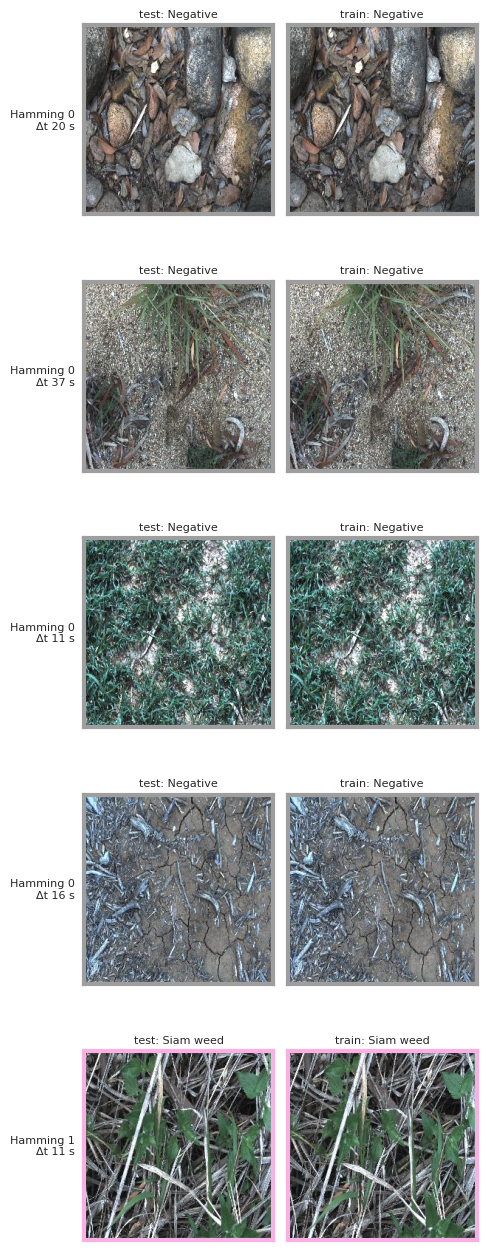

In [13]:
train_fold = FOLDS[0]["train"]["Filename"].reset_index(drop=True)
test_fold = FOLDS[0]["test"]["Filename"].reset_index(drop=True)
hashes_train = np.stack([hash_diferencial(DIR_IMAGENES / nombre) for nombre in train_fold])
hashes_test = np.stack([hash_diferencial(DIR_IMAGENES / nombre) for nombre in test_fold])

indice_vecino, distancia_vecino = vecino_mas_cercano(hashes_test, hashes_train)
label_maestro = etiquetas.set_index("Filename")["Label"]
momentos = metadatos_por_nombre["momento"]

cercanos = pd.DataFrame({"test": test_fold,
                         "train": train_fold.iloc[indice_vecino].to_numpy(),
                         "distancia": distancia_vecino})
cercanos["misma_clase"] = (cercanos["test"].map(label_maestro).to_numpy()
                           == cercanos["train"].map(label_maestro).to_numpy())
cercanos["segundos"] = (cercanos["test"].map(momentos)
                        - cercanos["train"].map(momentos)).abs().dt.total_seconds()

resumen_hash = pd.DataFrame(
    [{"% del test con casi duplicado en train": 100 * (cercanos["distancia"] <= d).mean(),
      "de ellos, % de otra clase": 100 * (~cercanos.loc[cercanos["distancia"] <= d, "misma_clase"]).mean(),
      "de ellos, mediana de Δt (s)": cercanos.loc[cercanos["distancia"] <= d, "segundos"].median()}
     for d in DISTANCIAS_HASH],
    index=pd.Index(DISTANCIAS_HASH, name="distancia de Hamming ≤")).round(1)
display(resumen_hash)

figura = graficar_pares(cercanos.nsmallest(PARES_A_MOSTRAR, "distancia"), DIR_IMAGENES,
                        metadatos_por_nombre["Species"], COLORES_CLASE)
figura.savefig(DIR_FIGURAS / "casi_duplicados_test_train.png", bbox_inches="tight")
plt.show()

#### Validación: pares de clases distintas

Se inspeccionan los pares de clases distintas que aparecen con el umbral más permisivo (distancia ≤ 10), para determinar si son errores de etiqueta o falsos positivos del hash.

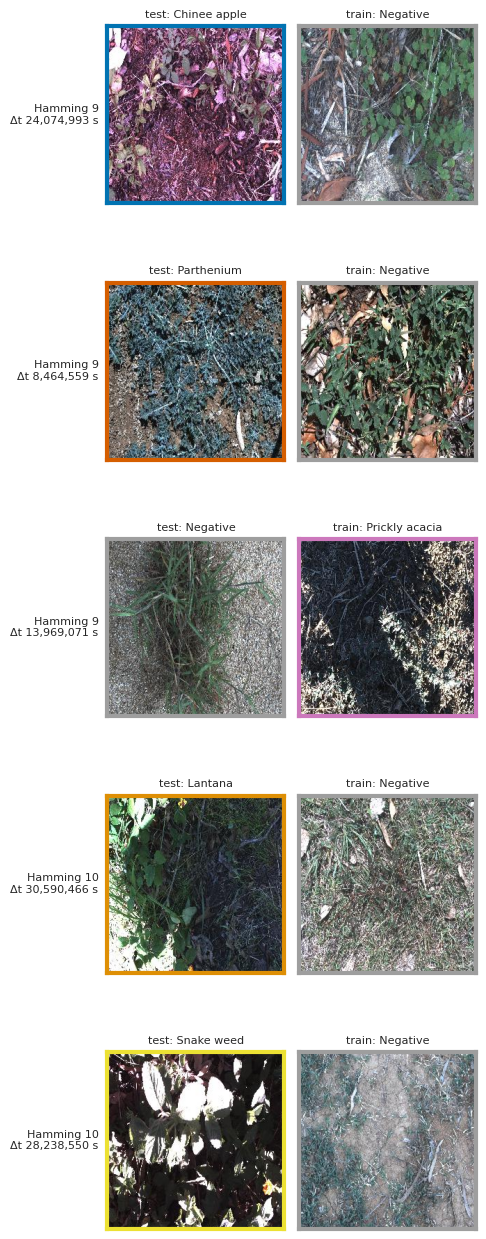

In [14]:
UMBRAL_PERMISIVO = 10

otra_clase = cercanos[(cercanos["distancia"] <= UMBRAL_PERMISIVO) & ~cercanos["misma_clase"]]
if otra_clase.empty:
    print(f"No hay pares de clases distintas con distancia ≤ {UMBRAL_PERMISIVO}.")
else:
    figura = graficar_pares(otra_clase.nsmallest(PARES_A_MOSTRAR, "distancia"), DIR_IMAGENES,
                            metadatos_por_nombre["Species"], COLORES_CLASE)
    figura.savefig(DIR_FIGURAS / "falsos_positivos_hash.png", bbox_inches="tight")
    plt.show()

#### Distribución de la distancia al vecino más cercano

Para determinar a partir de qué distancia las coincidencias del hash se deben al azar, se describe la distancia entre cada imagen de test y su vecina más cercana en train.

In [15]:
display(cercanos["distancia"].describe(percentiles=[0.01, 0.05, 0.25, 0.5])
        .round(1).to_frame("distancia al vecino más cercano"))

,distancia al vecino más cercano
count,3507.0
mean,15.2
std,1.9
min,0.0
1%,10.0
5%,12.0
25%,14.0
50%,15.0
max,19.0


**Observación:**
- De 60 días de captura, 21 tuvieron una sola especie de maleza. Además, algunas especies están asociadas a un instrumento: Snake weed (85 %) y Chinee apple (59 %) fueron fotografiadas en su mayoría con el instrumento 0, justo el par de especies que más confunde el modelo de Olsen et al. (2019).
- La documentación indica instrumentos 0–3, pero los datos incluyen también el instrumento 4 (27 imágenes).
- Con una ventana de 5 s, el 24.4 % del test tiene una imagen de la misma clase en train; con 60 s, el 94.7 %. Esto se debe a que las fotos se tomaron en ráfaga y la partición fue aleatoria imagen por imagen. En una partición simulada del tipo de Duong et al. (2024), con 80 % en train, los valores suben a 31.1 % y 97.4 %.
- Sin embargo, solo el 0.7 % del test tiene un casi duplicado visual en train (distancia de Hamming ≤ 6). La mayoría de las gemelas temporales no son imágenes casi idénticas, sino vistas distintas de la misma sesión de captura. Los casi duplicados encontrados son de la misma clase, con 10 a 37 s de diferencia y sin movimiento aparente de la cámara.
- Con un umbral más permisivo (distancia ≤ 10) aparecen pares de clases distintas, pero la inspección visual muestra que son imágenes completamente diferentes. Son coincidencias por azar: el hash resume cada imagen en solo 64 bits, y al comparar cada imagen de test con 10501 de train, la más cercana está típicamente a 15 bits (mediana), y el 1 % llega a 10 sin parecerse. Los casi duplicados con distancia ≤ 6 están muy por debajo de ese ruido de fondo, por lo que solo ese umbral se considera confiable. No hay evidencia de errores de etiqueta por esta vía.
- Duong et al. (2024) no especifican si el augmentation se aplicó antes o después de la partición.
- **Limitación:** la memorización de imágenes casi idénticas tiene un efecto pequeño, pero train y test comparten sesiones, lugares y condiciones de captura. Por eso, el accuracy en test mide qué tan bien reconoce el modelo fotos nuevas de los mismos lugares y sesiones, no de un terreno nuevo. Esto aplica también a Olsen et al. y Duong et al.; en consecuencia, la comparación entre el 95.7 % de Olsen et al. y el 99.26 % de Duong et al. no aísla por completo el efecto de la arquitectura, aunque no es posible estimar cuánto aporta la partición. Se mantienen las particiones oficiales porque cambiarlas implicaría perder la comparación directa con Olsen et al.

## 9. Inspección visual por clase

Se muestran imágenes aleatorias de cada clase para observar la variabilidad dentro de cada una (escala, iluminación, fondo, enfoque) y las similitudes entre clases. El borde de cada imagen usa el color de su clase y el título indica el instrumento que la capturó.

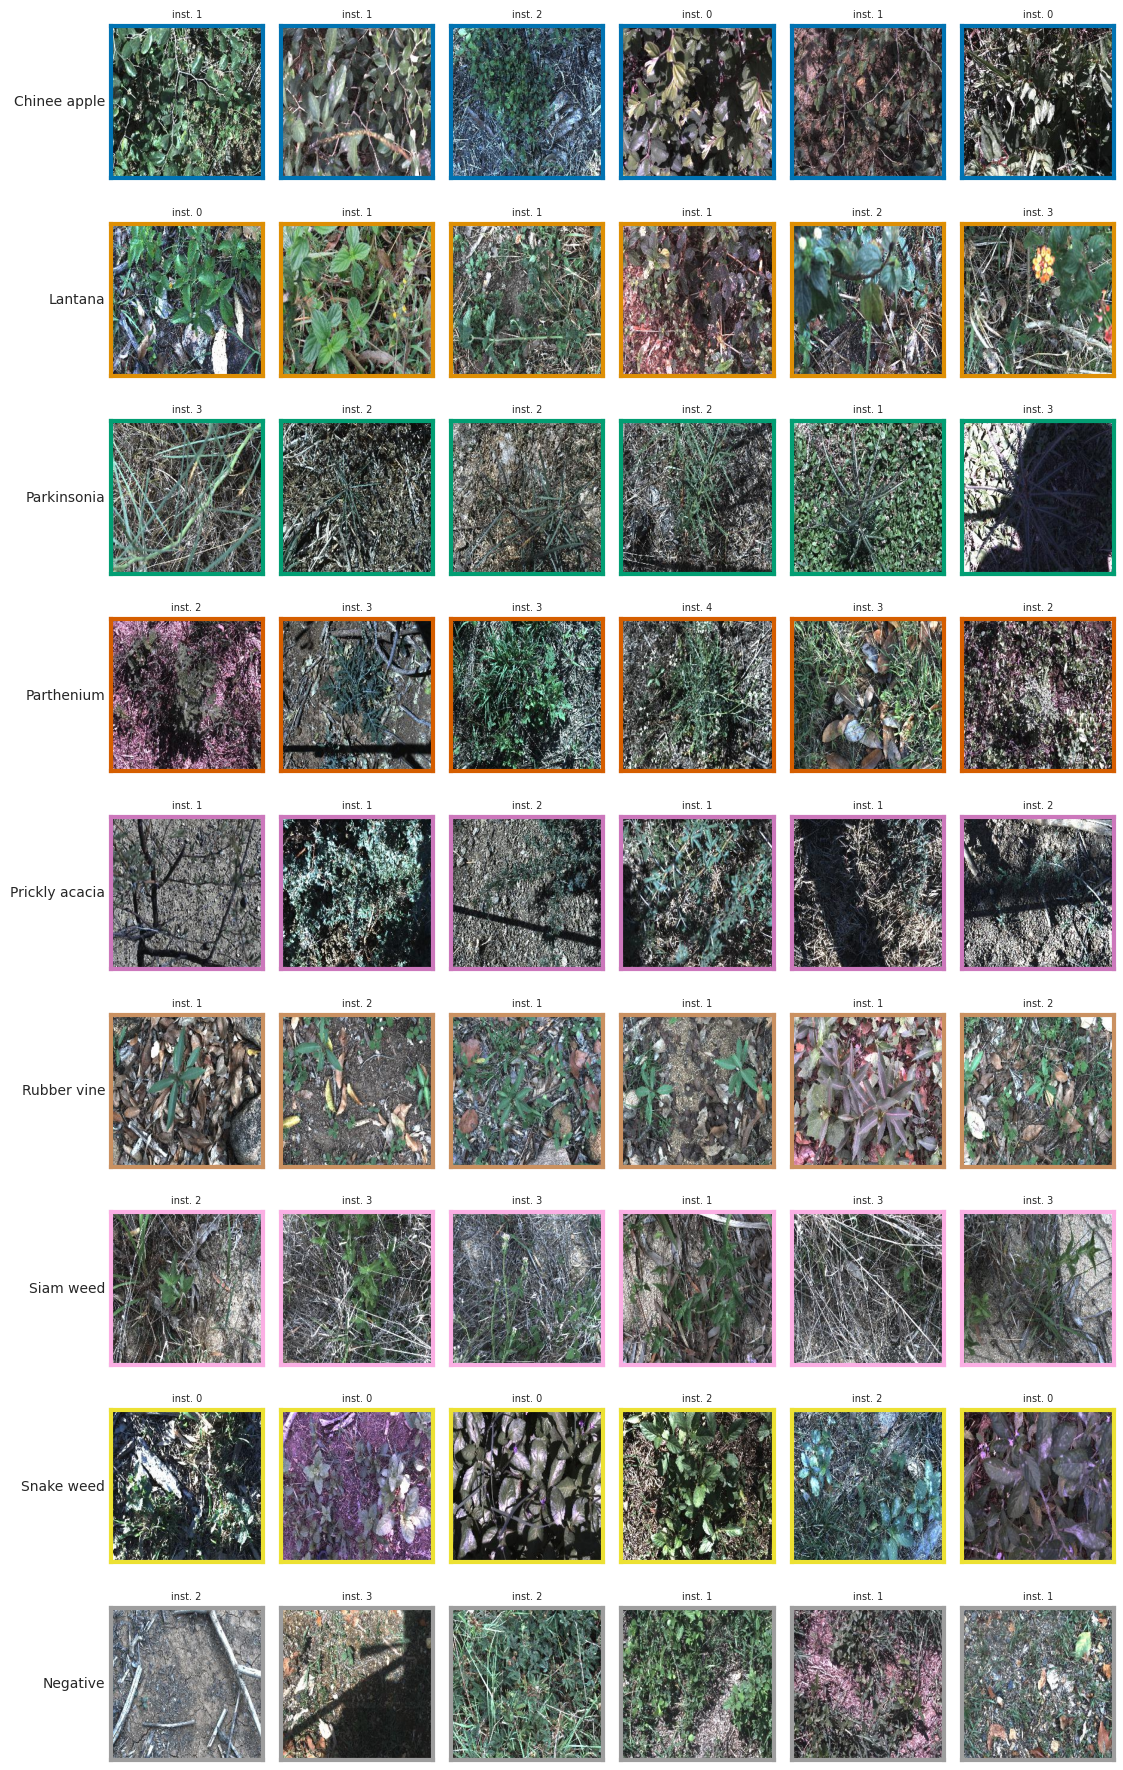

In [16]:
IMAGENES_POR_CLASE = 6


def graficar_muestras(metadatos: pd.DataFrame, carpeta: Path, colores: dict[str, tuple],
                      por_clase: int, semilla: int) -> plt.Figure:
    """Construye una grilla con imágenes aleatorias de cada clase.

    Cada fila es una clase, en el orden de sus Labels. El borde de cada imagen
    usa el color de su clase y el título indica el instrumento que la capturó.

    Args:
        metadatos: Debe contener las columnas Filename, Label, Species e instrumento.
        carpeta: Carpeta que contiene las imágenes.
        colores: Color de cada clase, resultado de 'asignar_colores'.
        por_clase: Número de imágenes por clase.
        semilla: Semilla del muestreo, para mostrar siempre las mismas imágenes.

    Returns:
        Figura con la grilla de imágenes.
    """
    clases = list(dict.fromkeys(metadatos.sort_values("Label")["Species"]))
    fig, ejes = plt.subplots(len(clases), por_clase,
                             figsize=(1.9 * por_clase, 2.0 * len(clases)))
    for fila, clase in zip(ejes, clases):
        muestra = metadatos[metadatos["Species"] == clase].sample(por_clase, random_state=semilla)
        for eje, (nombre, instrumento) in zip(fila, muestra[["Filename", "instrumento"]]
                                                    .itertuples(index=False)):
            with Image.open(carpeta / nombre) as imagen:
                eje.imshow(np.asarray(imagen))
            eje.set_title(f"inst. {instrumento}", fontsize=7)
            eje.set_xticks([])
            eje.set_yticks([])
            for borde in eje.spines.values():
                borde.set_edgecolor(colores[clase])
                borde.set_linewidth(3)
        fila[0].set_ylabel(clase, rotation=0, ha="right", va="center", fontsize=10)
    fig.tight_layout()
    return fig


figura = graficar_muestras(metadatos, DIR_IMAGENES, COLORES_CLASE, IMAGENES_POR_CLASE, SEED)
figura.savefig(DIR_FIGURAS / "muestras_por_clase.png", bbox_inches="tight")
plt.show()

**Observación:**
- Chinee apple y Snake weed comparten rasgos visuales: hojas alargadas que terminan en punta y tonos de color parecidos, lo que coincide con la confusión entre ambas reportada por Olsen et al. (2019, Tabla 3).
- En esta muestra no se aprecia similitud entre Parkinsonia y Prickly acacia. Olsen et al. atribuyen su parecido a espinas, flores amarillas y vainas, rasgos que no siempre aparecen en una imagen; además, la confusión que reportan entre ambas es baja (1.26 %).
- Negative es la clase más variada: incluye suelo con ramas secas, pasto, hojarasca y otras plantas, lo que es coherente con que agrupe todo lo que no es maleza objetivo.
- Las imágenes del instrumento 0 parecen más brillantes y nítidas. Como Snake weed y Chinee apple se capturaron mayoritariamente con ese instrumento, el modelo podría usar el brillo o la nitidez como atajo en lugar de la forma de la planta.
- Hay casos difíciles: imágenes con sombras, vegetación seca de fondo y poca nitidez. Las imágenes de Prickly acacia, en particular, parecen de menor calidad.
- Estas son impresiones sobre 6 imágenes por clase; en la siguiente sección se verifican con estadísticas sobre una muestra mayor.

## 10. Color, brillo y nitidez

Se verifican con estadísticas las impresiones de la inspección visual. Para cada imagen de una muestra se calcula:

- **Color medio** de los canales R, G y B.
- **Brillo**: media de la imagen en escala de grises (0–255).
- **Nitidez**: varianza del Laplaciano. Mide qué tan definidos son los bordes; valores bajos indican imágenes desenfocadas. También depende de la textura de la escena, por lo que es una medida aproximada.

Si una clase se distingue solo por su color, brillo o nitidez, el modelo podría usar esas propiedades como atajo en lugar de la forma de la planta.

In [17]:
MUESTRA_POR_GRUPO = 200
PESOS_LUMINANCIA = np.array([0.299, 0.587, 0.114])
COLUMNAS_IMAGEN = ["R", "G", "B", "brillo", "nitidez"]


def muestrear_por_grupo(datos: pd.DataFrame, columna: str, n: int, semilla: int) -> pd.DataFrame:
    """Toma hasta 'n' filas al azar de cada valor de 'columna'."""
    return pd.concat([grupo.sample(min(n, len(grupo)), random_state=semilla)
                      for _, grupo in datos.groupby(columna)])


def calcular_estadisticas_imagen(ruta: Path) -> dict[str, float]:
    """Calcula el color medio, el brillo y la nitidez de una imagen.

    El brillo es la media de la imagen en escala de grises, con los pesos de
    luminancia de la norma ITU-R BT.601. La nitidez es la varianza del
    Laplaciano: valores altos indican bordes definidos. También depende de la
    textura de la escena, por lo que es una medida aproximada del enfoque.

    Args:
        ruta: Ruta de la imagen.

    Returns:
        Medias de los canales R, G y B, brillo (escala 0–255) y nitidez.
    """
    with Image.open(ruta) as imagen:
        rgb = np.asarray(imagen.convert("RGB"), dtype=np.float32)
    gris = rgb @ PESOS_LUMINANCIA
    laplaciano = (gris[:-2, 1:-1] + gris[2:, 1:-1] + gris[1:-1, :-2] + gris[1:-1, 2:]
                  - 4 * gris[1:-1, 1:-1])
    r, g, b = rgb.reshape(-1, 3).mean(axis=0)
    return {"R": float(r), "G": float(g), "B": float(b),
            "brillo": float(gris.mean()), "nitidez": float(laplaciano.var())}


def agregar_estadisticas(muestra: pd.DataFrame, carpeta: Path) -> pd.DataFrame:
    """Agrega a cada fila de la muestra las estadísticas de su imagen.

    Args:
        muestra: Debe contener la columna Filename.
        carpeta: Carpeta que contiene las imágenes.

    Returns:
        La muestra con las columnas R, G, B, brillo y nitidez.
    """
    estadisticas = [calcular_estadisticas_imagen(carpeta / nombre) for nombre in muestra["Filename"]]
    return pd.concat([muestra.reset_index(drop=True), pd.DataFrame(estadisticas)], axis=1)


def graficar_brillo_nitidez(estadisticas: pd.DataFrame, colores: dict[str, tuple],
                            ruta_salida: Path) -> None:
    """Grafica la distribución de brillo y nitidez por clase y guarda la figura."""
    orden = list(dict.fromkeys(estadisticas.sort_values("Label")["Species"]))
    fig, ejes = plt.subplots(1, 2, figsize=(15, 4.8))
    for eje, (columna, titulo) in zip(ejes, [("brillo", "Brillo (0–255)"),
                                             ("nitidez", "Nitidez (varianza del Laplaciano)")]):
        sns.boxplot(data=estadisticas, x="Species", y=columna, order=orden, hue="Species",
                    palette=colores, legend=False, ax=eje)
        eje.set(title=titulo, xlabel="", ylabel="")
        plt.setp(eje.get_xticklabels(), rotation=40, ha="right")
    ejes[1].set_yscale("log")
    fig.tight_layout()
    fig.savefig(ruta_salida, bbox_inches="tight")
    plt.show()

### Diferencias entre clases

,R,G,B,brillo,nitidez
Species,,,,,
Chinee apple,85.1,88.5,83.8,86.5,13989.8
Lantana,89.6,103.7,95.0,99.2,16214.9
Parkinsonia,88.7,94.7,88.8,91.7,28871.6
Parthenium,85.6,87.8,86.8,86.7,27864.3
Prickly acacia,82.1,86.3,87.1,85.1,36006.0
Rubber vine,98.4,105.5,100.1,103.2,10547.5
Siam weed,103.6,110.2,104.0,107.3,16693.7
Snake weed,87.1,85.2,86.5,86.0,13145.9
Negative,101.6,102.2,101.1,101.6,17375.3


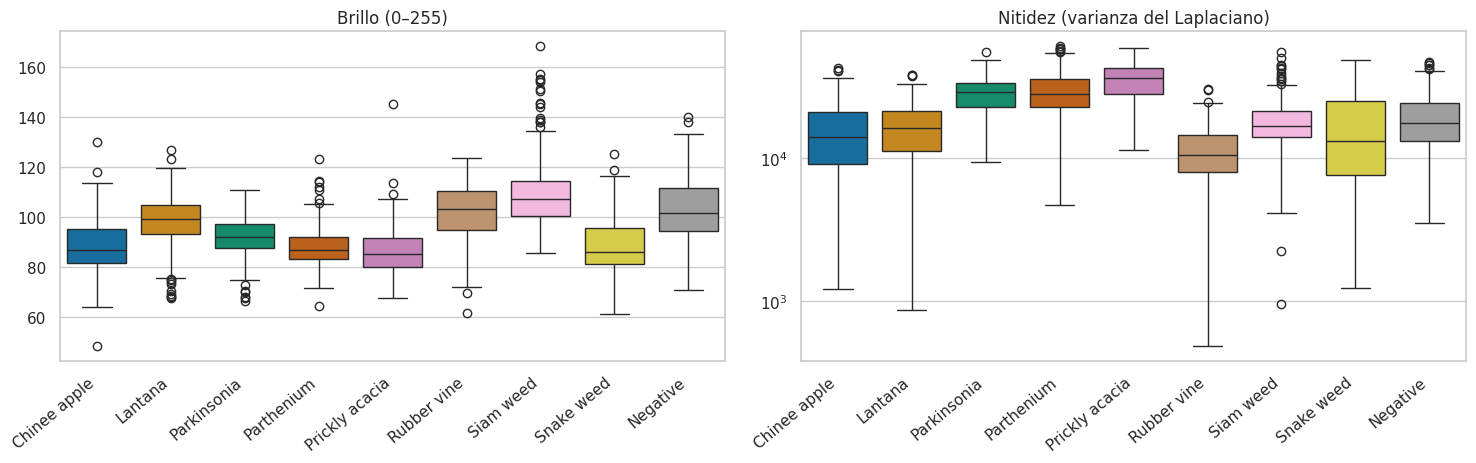

In [18]:
muestra_clases = agregar_estadisticas(
    muestrear_por_grupo(metadatos, "Species", MUESTRA_POR_GRUPO, SEED), DIR_IMAGENES)

orden_clases = list(dict.fromkeys(muestra_clases.sort_values("Label")["Species"]))
display(muestra_clases.groupby("Species")[COLUMNAS_IMAGEN].median().loc[orden_clases].round(1))
graficar_brillo_nitidez(muestra_clases, COLORES_CLASE, DIR_FIGURAS / "brillo_nitidez_por_clase.png")

### Efecto del instrumento

El instrumento está asociado a la especie (sección 8), por lo que comparar instrumentos sobre todo el dataset mezclaría ambos efectos. Para aislar el efecto del instrumento se compara solo dentro de la clase Negative, que tiene imágenes de los instrumentos 0 a 3.

In [19]:
negative = metadatos[metadatos["Label"] == LABEL_NEGATIVE]
muestra_negative = agregar_estadisticas(
    muestrear_por_grupo(negative, "instrumento", MUESTRA_POR_GRUPO, SEED), DIR_IMAGENES)

display(muestra_negative.groupby("instrumento")
        .agg(imagenes=("Filename", "size"),
             brillo=("brillo", "median"),
             nitidez=("nitidez", "median"))
        .round(1))

,imagenes,brillo,nitidez
instrumento,,,
0,200,92.4,22088.9
1,200,104.0,17288.4
2,200,102.7,19139.4
3,200,102.3,17774.8


### Imágenes problemáticas

Se identifican, dentro de la muestra, las imágenes más oscuras, más brillantes y menos nítidas, y se cuenta a qué clase pertenece el 5 % más extremo en cada criterio. Si los casos extremos se concentran en una clase, esa clase tendrá más imágenes difíciles de clasificar.

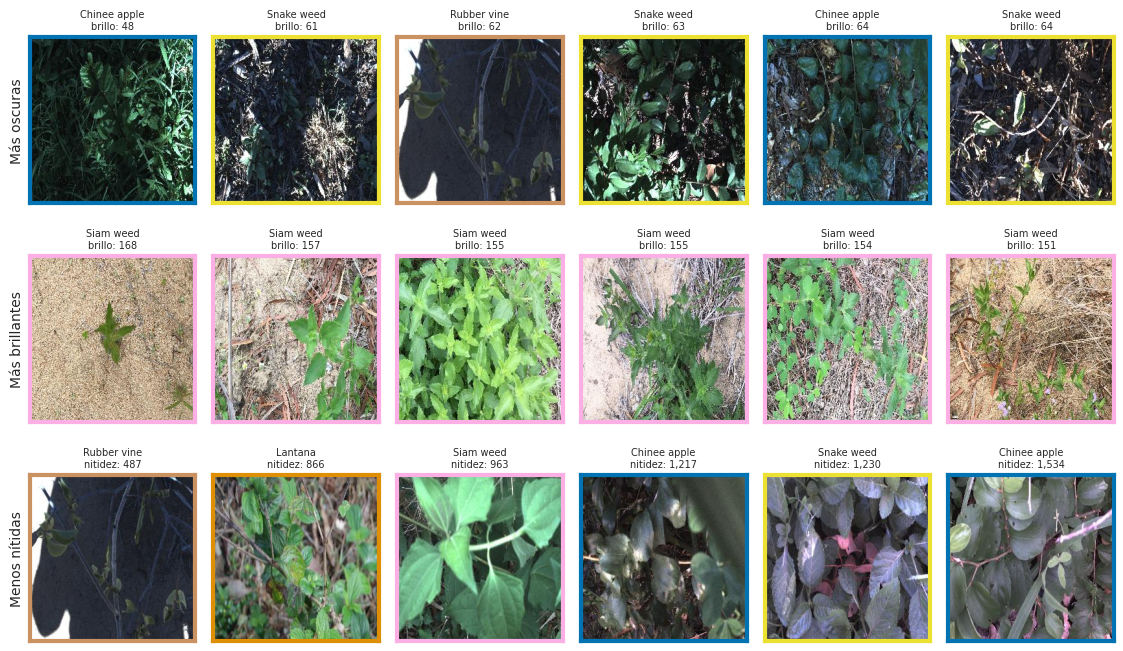

Clase de las 90 imágenes más extremas por criterio:


,Más oscuras,Más brillantes,Menos nítidas
Species,,,
Chinee apple,20,2,24
Lantana,9,4,14
Parkinsonia,8,0,0
Parthenium,5,1,1
Prickly acacia,17,1,0
Rubber vine,8,13,17
Siam weed,0,40,3
Snake weed,20,2,29
Negative,3,27,2


In [20]:
IMAGENES_POR_CRITERIO = 6
FRACCION_EXTREMOS = 0.05
CRITERIOS_EXTREMOS = [("brillo", True, "Más oscuras"),
                      ("brillo", False, "Más brillantes"),
                      ("nitidez", True, "Menos nítidas")]


def graficar_extremos(estadisticas: pd.DataFrame, criterios: list[tuple[str, bool, str]],
                      carpeta: Path, colores: dict[str, tuple], n: int) -> plt.Figure:
    """Muestra las imágenes con los valores más extremos de cada criterio.

    Args:
        estadisticas: Resultado de `agregar_estadisticas`, con las columnas
            Filename, Species y las métricas de cada criterio.
        criterios: Tuplas (columna, ascendente, título) que definen cada fila.
        carpeta: Carpeta que contiene las imágenes.
        colores: Color de cada clase, resultado de `asignar_colores`.
        n: Número de imágenes por criterio.

    Returns:
        Figura con una fila por criterio.
    """
    fig, ejes = plt.subplots(len(criterios), n, figsize=(1.9 * n, 2.3 * len(criterios)))
    for fila, (columna, ascendente, titulo) in zip(ejes, criterios):
        extremos = estadisticas.sort_values(columna, ascending=ascendente).head(n)
        for eje, (nombre, clase, valor) in zip(fila, extremos[["Filename", "Species", columna]]
                                                    .itertuples(index=False)):
            with Image.open(carpeta / nombre) as imagen:
                eje.imshow(np.asarray(imagen))
            eje.set_title(f"{clase}\n{columna}: {valor:,.0f}", fontsize=7)
            eje.set_xticks([])
            eje.set_yticks([])
            for borde in eje.spines.values():
                borde.set_edgecolor(colores[clase])
                borde.set_linewidth(3)
        fila[0].set_ylabel(titulo, fontsize=10)
    fig.tight_layout()
    return fig


figura = graficar_extremos(muestra_clases, CRITERIOS_EXTREMOS, DIR_IMAGENES, COLORES_CLASE,
                           IMAGENES_POR_CRITERIO)
figura.savefig(DIR_FIGURAS / "imagenes_extremas.png", bbox_inches="tight")
plt.show()

n_extremos = int(FRACCION_EXTREMOS * len(muestra_clases))
conteo_extremos = pd.DataFrame({
    titulo: muestra_clases.sort_values(columna, ascending=ascendente)
                          .head(n_extremos)["Species"].value_counts()
    for columna, ascendente, titulo in CRITERIOS_EXTREMOS
}).reindex(orden_clases).fillna(0).astype(int)
print(f"Clase de las {n_extremos} imágenes más extremas por criterio:")
display(conteo_extremos)

**Observación:**
- Chinee apple y Snake weed son casi idénticas en color medio, brillo (≈86) y nitidez (≈13000–14000), lo que confirma su similitud visual y es coherente con la confusión entre ambas reportada por Olsen et al. (2019). Además, concentran las imágenes más oscuras (20 y 20 de 90, cuando se esperarían ≈10 por clase) y menos nítidas (24 y 29 de 90): el par de especies más parecido es también el que tiene más imágenes de baja calidad.
- Prickly acacia, que en la inspección visual parecía de baja calidad, tiene la nitidez más alta (≈36000). La varianza del Laplaciano aumenta con el detalle fino de la escena (hojas pequeñas, espinas, ramas), por lo que esa impresión se explica mejor por escenas muy cargadas que por desenfoque.
- La métrica de nitidez detecta escenas con pocos bordes, no solo desenfoque: de las 6 imágenes menos nítidas, solo 2 están desenfocadas; las demás tienen poco detalle o sombras, incluida la sombra de una persona.
- Dentro de Negative, las imágenes del instrumento 0 son más nítidas (≈22000 vs. 17000–19000) pero más oscuras (brillo 92 vs. ≈103). Como Snake weed y Chinee apple se capturaron mayoritariamente con ese instrumento, parte de su menor brillo podría deberse a las condiciones de captura y no a la planta.
- El brillo varía entre ≈85 y ≈107 según la clase, y Siam weed concentra las imágenes más brillantes (40 de 90). Para evitar que el modelo use el brillo como atajo, en el preprocesado se aplicará augmentation de brillo, como en Olsen et al. (2019).

## 11. Conclusiones y decisiones para el preprocesado


### Cifras clave

In [21]:
UMBRAL_CASI_DUPLICADO = 6

gemelas_5s = comparacion_gemelas.loc[5]
cifras_clave = pd.Series({
    "Imágenes": f"{len(etiquetas):}",
    "Imágenes corruptas / duplicados exactos": f"{int(auditoria['corrupta'].sum())} / {len(duplicados)}",
    "Etiquetas discrepantes en las particiones": f"{len(discrepancias)}",
    "ρ problema plano (9 clases)": f"{ratio_desbalance(vistas['Plano (9 clases)']):.2f}",
    "ρ etapa 1 (Negative vs. Positiva)": f"{ratio_desbalance(vistas['Etapa 1: Negative vs. Positiva']):.2f}",
    "ρ etapa 2 (8 especies)": f"{ratio_desbalance(vistas['Etapa 2: 8 especies']):.2f}",
    "% test con gemela temporal ≤ 5 s (Olsen, fold 0)": f"{gemelas_5s.iloc[0]:.1f}",
    "% test con gemela temporal ≤ 5 s (tipo Duong)": f"{gemelas_5s.iloc[1]:.1f}",
    f"% test con casi duplicado visual (Hamming ≤ {UMBRAL_CASI_DUPLICADO})":
        f"{100 * (cercanos['distancia'] <= UMBRAL_CASI_DUPLICADO).mean():.1f}",
}, name="Valor")
display(cifras_clave.to_frame())

,Valor
Imágenes,17509
Imágenes corruptas / duplicados exactos,0 / 0
Etiquetas discrepantes en las particiones,1
ρ problema plano (9 clases),9.02
ρ etapa 1 (Negative vs. Positiva),1.08
ρ etapa 2 (8 especies),1.11
"% test con gemela temporal ≤ 5 s (Olsen, fold 0)",24.4
% test con gemela temporal ≤ 5 s (tipo Duong),31.1
% test con casi duplicado visual (Hamming ≤ 6),0.7


### Hallazgos

**Calidad de los datos**
- El dataset está completo y sin errores técnicos: 17509 imágenes RGB de 256×256, sin archivos corruptos ni duplicados exactos.
- Se encontró una imagen con etiqueta distinta entre `labels.csv` y los archivos de partición, y un instrumento (4) no documentado. Ninguno de los dos casos aparece en el artículo original ni en el repositorio oficial.

**Desbalance y estrategia jerárquica**
- El desbalance no está en las especies, sino en la formulación del problema: el ratio pasa de 9.02 (plano) a 1.08 (etapa 1) y 1.11 (etapa 2). La estrategia jerárquica elimina el desbalance sin modificar los datos.
- Que las especies estén balanceadas no garantiza que el modelo las vaya a reconocer igual de bien: Chinee apple y Snake weed son casi idénticas en color, brillo y nitidez, y además concentran las imágenes más oscuras y menos nítidas.

**Particiones y fuga de datos**
- Las 5 particiones oficiales forman una validación cruzada sin solapamiento entre train, val y test, y conservan las proporciones de ambas etapas. Las vistas jerárquicas pueden construirse sobre ellas sin fuga.
- Train y test comparten sesiones de captura (24.4 % del test tiene una imagen de la misma clase en train a menos de 5 s), aunque los casi duplicados visuales son escasos (0.7 %). En una partición del tipo de Duong et al. (2024), las gemelas temporales aumentan.

**Características visuales**
- Algunas especies están asociadas a un instrumento (Snake weed 85 % y Chinee apple 59 % con el instrumento 0), que produce imágenes más oscuras y nítidas. Siam weed concentra las imágenes más brillantes. Brillo e instrumento son posibles atajos para el modelo.

### Decisiones para el cuaderno 02 (preprocesado)

| Decisión | Justificación |
|---|---|
| Usar las particiones oficiales, empezando por el fold 0 | Comparabilidad con Olsen et al. (2019) (§7) |
| Tomar las etiquetas de `labels.csv`; la partición solo asigna el subconjunto | Fuente de verdad ante la discrepancia encontrada (§7) |
| Construir la etapa 1 (Negative vs. Positiva) y la etapa 2 (solo positivas) como vistas de la misma partición | Evaluación *end-to-end* sin fuga (§6, §7) |
| Llevar las imágenes de 256×256 a 224×224 | Tamaño de entrada de los backbones preentrenados (§5) |
| Normalizar con media y desviación del train para la CNN desde cero, y con `preprocess_input` de cada backbone para transfer learning; el pipeline recibe el backbone como parámetro | Coherencia con los pesos preentrenados y comparación de backbones |
| Aplicar augmentation de brillo, rotación, escala y volteos, solo en train | Reducir atajos de brillo e instrumento (§8, §10), como en Olsen et al. (2019) |

### Decisiones para los cuadernos de modelado

- **Línea base plana (9 clases):** usar ponderación de clases para compensar el ratio de 9.02.
- **Estrategia jerárquica:** no usar ponderación, porque los ratios de 1.08 y 1.11 la hacen innecesaria.
- **Evaluación:** reportar F1 por clase, F1 macro y matriz de confusión, y evaluar el pipeline jerárquico de forma aislada (*oracle*) y completa (*end-to-end*).
- **Análisis de errores:** verificar la confusión entre Chinee apple y Snake weed, y si los errores se concentran en imágenes oscuras, poco nítidas o del instrumento 0.

### Limitaciones

- El accuracy en test mide la generalización a nuevas imágenes de los mismos lugares y sesiones, no a un terreno nuevo. Esto aplica también a Olsen et al. (2019) y Duong et al. (2024), por lo que la comparación entre sus resultados no aísla por completo el efecto de la arquitectura.
- El hash perceptual detecta solo imágenes casi idénticas; el 0.7 % es un mínimo.
- La nitidez (varianza del Laplaciano) también depende de la textura de la escena.
- El efecto del instrumento se aisló de la especie, pero no del lugar ni de la fecha de captura.
- La ubicación de captura no está en los metadatos del dataset; se toma de la Tabla 1 de Olsen et al. (2019).

### Referencias
- A. Olsen et al., "DeepWeeds: A multiclass weed species image dataset for deep learning," *Scientific Reports*, vol. 9, art. 2058, 2019.
- L. T. Duong et al., "Automatic detection of weeds: synergy between EfficientNet and transfer learning to enhance the prediction accuracy," *Soft Computing*, vol. 28, pp. 5029–5044, 2024.
- A. Olsen, "DeepWeeds," repositorio de GitHub. https://github.com/AlexOlsen/DeepWeeds
- Imsparsh, "DeepWeeds," Kaggle, 2019. https://www.kaggle.com/datasets/imsparsh/deepweeds